In [2]:
import pandas as pd
import numpy as np
import os

os.getcwd()

'/Users/shankernarayan/Documents/Project_Datasets/instacart'

# Load Data

In [3]:
aisles = pd.read_csv('/Users/shankernarayan/Documents/Project_Datasets/instacart/data/aisles.csv')
departments = pd.read_csv('/Users/shankernarayan/Documents/Project_Datasets/instacart/data/departments.csv')
order_products_prior = pd.read_csv('/Users/shankernarayan/Documents/Project_Datasets/instacart/data/order_products__prior.csv')
order_products_train = pd.read_csv('/Users/shankernarayan/Documents/Project_Datasets/instacart/data/order_products__train.csv')
orders = pd.read_csv('/Users/shankernarayan/Documents/Project_Datasets/instacart/data/orders.csv')
products = pd.read_csv('/Users/shankernarayan/Documents/Project_Datasets/instacart/data/products.csv')

In [121]:
aisles.head()
departments.head()
order_products_prior.head()
order_products_train.head()
orders.head()
products.head()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


# Customers and Orders Overview

In [9]:
orders['user_id'].nunique()

#There are 206,209 unique customers who have placed orders

206209

In [10]:
orders['order_id'].nunique()

#there are a total of 3,421,083 orders that have been made on Instacart

3421083

In [129]:
#total number of orders for every customer

cust_total_orders = (orders.groupby("user_id")
                     .agg(total_orders=("order_id", "count"))
                     .sort_values("total_orders", ascending=False)
                     .reset_index())
cust_total_orders

,user_id,total_orders
0,152340,100
1,185641,100
2,185524,100
3,81678,100
4,70922,100
...,...,...
206204,13046,4
206205,70208,4
206206,111440,4
206207,31762,4


In [123]:
#Average number of orders across all customers

cust_total_orders["total_orders"].mean()

16.590367054784224

In [124]:
#Median number of orders across all customers

cust_total_orders["total_orders"].median()

10.0

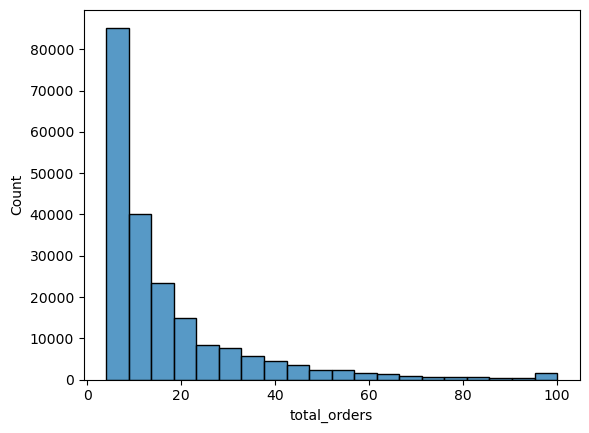

In [134]:
import seaborn as sns
import matplotlib.pyplot as plt

"""
The distribution of total orders per customer is strongly right-skewed. The majority of customers have placed 
fewer than 20 orders, while a smaller subset are highly active with 20–100+ orders.
"""

sns.histplot(data=cust_total_orders, x="total_orders", bins=20)
plt.show()

In [140]:
#Order counts

"""

11.6% of customers place 4 orders, 9.5% place 5 orders, etc...

"""

order_counts = cust_total_orders["total_orders"].value_counts().reset_index()

order_counts["pct"] = order_counts["count"] / order_counts["count"].sum()
order_counts["pct"] = order_counts["pct"].apply(lambda x: f"{x:.2%}")

order_counts


,total_orders,count,pct
0,4,23986,11.63%
1,5,19590,9.50%
2,6,16165,7.84%
3,7,13850,6.72%
4,8,11700,5.67%
...,...,...,...
92,94,57,0.03%
93,91,56,0.03%
94,97,54,0.03%
95,98,50,0.02%


# Order Timing

In [35]:
#What is the average time between orders?
orders["days_since_prior_order"].mean()

11.114836226863012

##### When looking at days of the week, most orders are placed on Sunday or Monday

Text(0.5, 1.0, 'Orders by Day of Week')

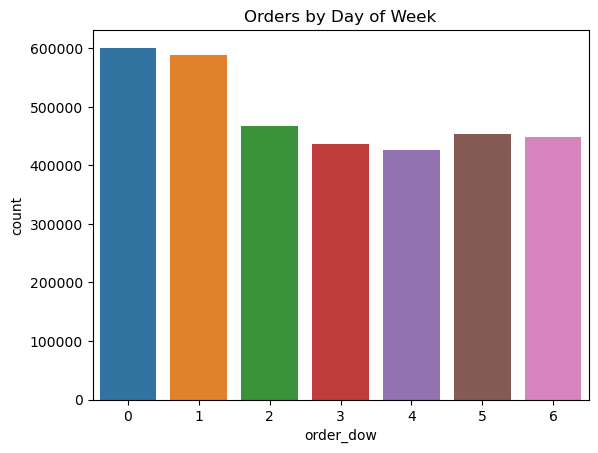

In [43]:
sns.countplot(x="order_dow", data=orders)
plt.title("Orders by Day of Week")

##### When looking at hour of day, most orders are placed during the morning to mid afternoon timeframe

Text(0.5, 1.0, 'Orders by Hour of Day')

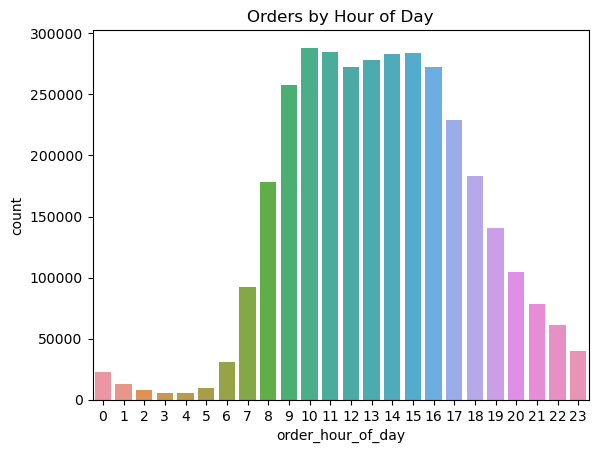

In [44]:
sns.countplot(x="order_hour_of_day", data=orders)
plt.title("Orders by Hour of Day")

##### KEY INSIGHT: Sunday afternoon and Monday morning are the most popular order times

Text(0.5, 1.0, 'Orders by Day and Hour')

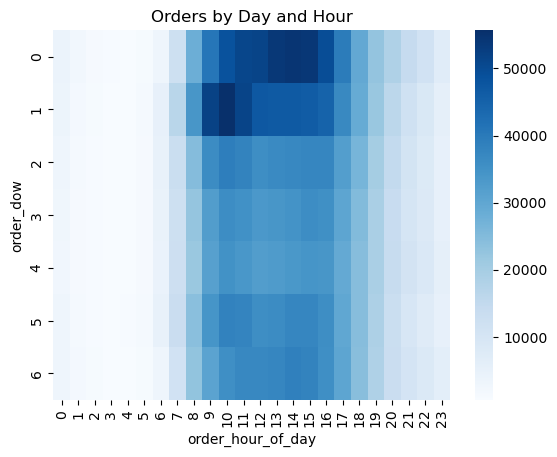

In [142]:
dow_hour = (
    orders.groupby(["order_dow", "order_hour_of_day"])
          .size()
          .reset_index(name="count")
)

pivot = dow_hour.pivot(
    index="order_dow",
    columns="order_hour_of_day",
    values="count"
)


sns.heatmap(pivot, cmap="Blues")
plt.title("Orders by Day and Hour")



# Basket Analysis

In [58]:
order_products_prior.head()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


##### The average basket size is 10 items per order across all customers

In [144]:
products_per_order = (order_products_prior
                      .groupby("order_id")
                      .agg(num_products=("product_id", "count"))
                      .sort_values("num_products", ascending=False)
                      .reset_index())
                      
products_per_order["num_products"].mean()

10.088883421247614

##### The median basket size is 8 items. Since it's less than the mean, it could indicate a right-skewed distribution with a small number of very large baskets

In [145]:
products_per_order["num_products"].median()

8.0

##### We see another right-skewed distribution, where fewer orders contain a large number of items. The majority of orders have a basket size of 15 items or fewer

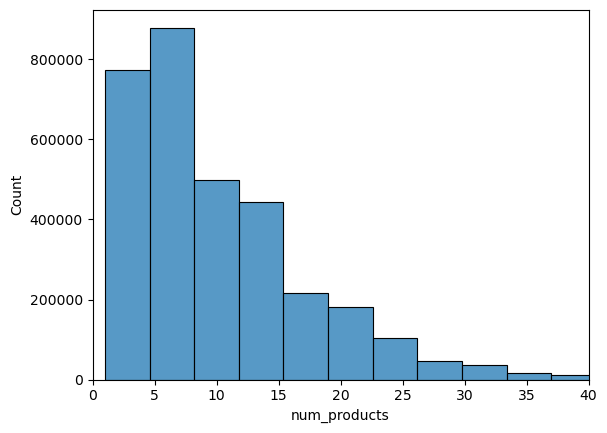

In [143]:
sns.histplot(data=products_per_order, x="num_products", bins=40)
plt.xlim(0, 40)
plt.show()

##### CONFIRMATION: Approximately 80% of baskets contain 15 or fewer items.

In [90]:
bins = [0, 5, 10, 15, 20, float("inf")]
labels = ["0–5 items", "6–10 items", "11–15 items", "16–20 items", "21+ items"]

products_per_order["basket_bucket"] = pd.cut(
    products_per_order["num_products"],
    bins=bins,
    labels=labels,
    right=True
)

counts_in_ranges = products_per_order["basket_bucket"].value_counts()
percentages = counts_in_ranges/counts_in_ranges.sum()
percentages.apply(lambda x: f"{x:.2%}")


basket_bucket
0–5 items      31.14%
6–10 items     31.14%
11–15 items    18.39%
16–20 items     9.89%
21+ items       9.44%
Name: count, dtype: object

##### Produce accounts for 29.23% of all items ordered, making it the most frequently purchased departments. The three most popular departments are produce, dairy eggs, and snacks

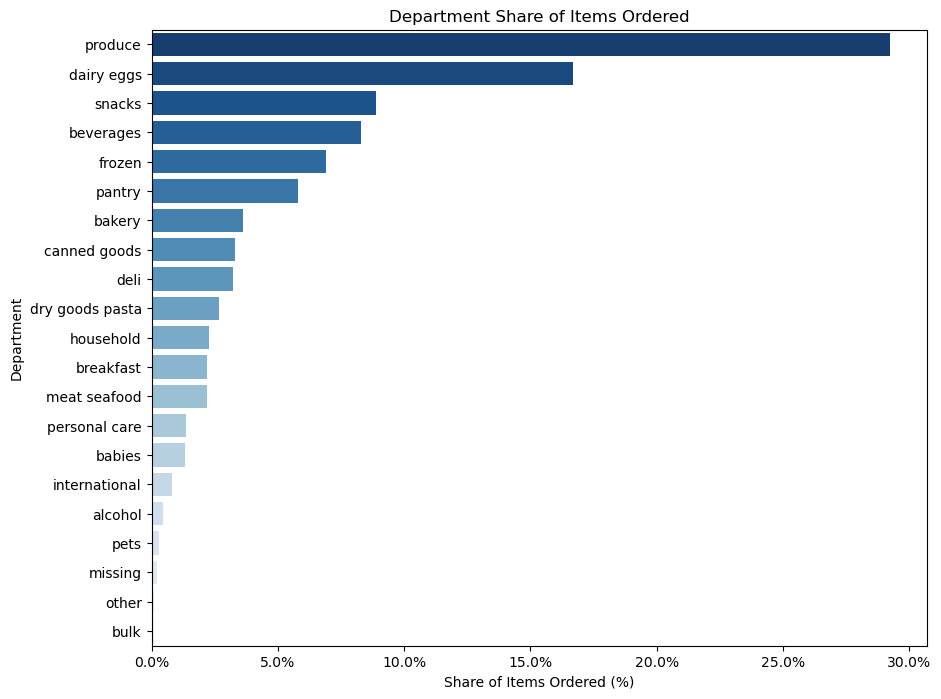

In [342]:
prod_dept = pd.merge(products, departments, on="department_id", how="left")
order_prod_dept = pd.merge(order_products_prior, prod_dept, on="product_id", how="left")

dept_share = order_prod_dept["department"].value_counts(normalize=True)
dept_df = dept_share.reset_index()
dept_df.columns = ["department", "share"]
dept_df

plt.figure(figsize=(10, 8))
sns.barplot(
    data=dept_df.sort_values("share", ascending=False),
    y="department",
    x="share",
    palette="Blues_r"
)

plt.title("Department Share of Items Ordered")
plt.xlabel("Share of Items Ordered (%)")
plt.ylabel("Department")

# Format x-axis as percentage
plt.gca().xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))

plt.show()

##### Instacart shoppers typically mix items across multiple categories in a single trip. The average basket spans about five departments, suggesting that customers often treat Instacart as a substitute for a full grocery trip rather than a quick ‘one-category’ run.

In [147]:
depts_within_orders = (order_prod_dept
                       .groupby("order_id")
                       .agg(unique_dept = ("department", "nunique"))
                       .reset_index())

depts_within_orders["unique_dept"].mean()

4.736172552952309

### Do customers buy different types of items when they are new users versus when they become repeat users? To answer this, let's look at data across 4 tables: orders, products, aisles, and order_products_prior

In [165]:
aisles.head(1) #gives us aisle_id and aisle_name

,aisle_id,aisle
0,1,prepared soups salads


##### We want to add aisle names to the product table

In [167]:
products.head(1)
prod_aisles = pd.merge(products, aisles, on="aisle_id", how = "left")
prod_aisles.head(1)

,product_id,product_name,aisle_id,department_id,aisle
0,1,Chocolate Sandwich Cookies,61,19,cookies cakes


##### We want to merge prod_aisles into the orders table, but we first need to use 'order_products_prior' in order to link the two

In [168]:
order_prod_link = pd.merge(order_products_prior, prod_aisles, on = "product_id", how = "left")
order_prod_link.head(1)

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle
0,2,33120,1,1,Organic Egg Whites,86,16,eggs


##### Now, we can create a cleaned up table that contains all relevant columns from orders, products, and aisles.

In [173]:
order_aisles = pd.merge(orders, order_prod_link, on = "order_id", how = "left")
order_aisles_clean = order_aisles[["order_id", "user_id", "order_number", 
                                   "product_id", "product_name", "aisle"]]
order_aisles_clean.head(20)

,order_id,user_id,order_number,product_id,product_name,aisle
0,2539329,1,1,196.0,Soda,soft drinks
1,2539329,1,1,14084.0,Organic Unsweetened Vanilla Almond Milk,soy lactosefree
2,2539329,1,1,12427.0,Original Beef Jerky,popcorn jerky
3,2539329,1,1,26088.0,Aged White Cheddar Popcorn,popcorn jerky
4,2539329,1,1,26405.0,XL Pick-A-Size Paper Towel Rolls,paper goods
5,2398795,1,2,196.0,Soda,soft drinks
6,2398795,1,2,10258.0,Pistachios,nuts seeds dried fruit
7,2398795,1,2,12427.0,Original Beef Jerky,popcorn jerky
8,2398795,1,2,13176.0,Bag of Organic Bananas,fresh fruits
9,2398795,1,2,26088.0,Aged White Cheddar Popcorn,popcorn jerky


##### Let's establish the following definitions for early, middle, and later orders for each customer/user

##### early: order_number <= 3
##### middle: 3 < order_number <= 9
##### later: order_number >= 10

In [179]:
early = order_aisles_clean[order_aisles_clean["order_number"] <= 3]

middle = order_aisles_clean[(order_aisles_clean["order_number"] > 3)
                            & (order_aisles_clean["order_number"] <= 9)]

later = order_aisles_clean[order_aisles_clean["order_number"] > 9]

##### Let's look at which aisles had the most purchases within early, middle, and later orders, expressed as percentages

In [224]:
early_pct = early["aisle"].value_counts(normalize=True)
middle_pct = middle["aisle"].value_counts(normalize=True)
later_pct = later["aisle"].value_counts(normalize = True)

##### Let's combine these into a single table

In [225]:
aisle_compare = pd.concat(
    [early_pct.rename("early"),
     middle_pct.rename("middle"),
     later_pct.rename("late")],
    axis=1
).fillna(0)

aisle_compare

,early,middle,late
aisle,,,
fresh vegetables,0.104074,0.104558,0.106241
fresh fruits,0.103813,0.106549,0.118055
packaged vegetables fruits,0.053161,0.053424,0.055358
yogurt,0.043101,0.043473,0.045999
packaged cheese,0.030435,0.030489,0.029991
...,...,...,...
skin care,0.000305,0.000320,0.000313
baby bath body care,0.000233,0.000241,0.000287
beauty,0.000224,0.000199,0.000174


###### We want to examine changes in purchasing patterns as customers go from new to long-term users. Let's create a new column to understand how baskets evolve over the lifecycle of each customer, within each aisle

In [226]:
aisle_compare["change_early_to_late"] = aisle_compare["late"] - aisle_compare["early"]
aisle_compare.sort_values("change_early_to_late").head(10)

,early,middle,late,change_early_to_late
aisle,,,,
frozen meals,0.014391,0.013481,0.010505,-0.003887
ice cream ice,0.016963,0.016885,0.014070,-0.002893
frozen produce,0.017150,0.016542,0.015544,-0.001606
soft drinks,0.011884,0.011796,0.010347,-0.001537
soup broth bouillon,0.011623,0.011060,0.010169,-0.001454
frozen pizza,0.005767,0.005562,0.004461,-0.001306
cereal,0.012421,0.012061,0.011165,-0.001256
instant foods,0.006895,0.006744,0.005669,-0.001226
hot dogs bacon sausage,0.010101,0.010050,0.008882,-0.001219


##### Fresh fruits, milk, and yogurt become slightly more prominent in customers’ baskets over time, suggesting that core staples play a growing role in routine, repeat ordering behavior. On the other hand, frozen meals, ice cream, and frozen produce do not seem to drive customer loyalty, but can help onboard new customers

In [230]:
aisle_compare.sort_values("change_early_to_late", ascending=False)

,early,middle,late,change_early_to_late
aisle,,,,
fresh fruits,0.103813,0.106549,0.118055,0.014242
milk,0.024370,0.025461,0.029534,0.005163
baby food formula,0.009746,0.010573,0.013100,0.003354
yogurt,0.043101,0.043473,0.045999,0.002897
water seltzer sparkling water,0.024329,0.025438,0.026758,0.002429
...,...,...,...,...
soup broth bouillon,0.011623,0.011060,0.010169,-0.001454
soft drinks,0.011884,0.011796,0.010347,-0.001537
frozen produce,0.017150,0.016542,0.015544,-0.001606


##### If the data above were to be used as part of a promotional strategy, deals related to frozen/quick items could be used to welcome new customers to Instacart, while deals around staples could be used as part of retention strategy

# Product and Category Analysis

##### What are the 10 most ordered products?

In [246]:
"""

The "order_aisles_clean" table contains the data we need, but let's rename it to make it 
more relevant for our current question

"""

order_products = order_aisles_clean
order_products.head()

,order_id,user_id,order_number,product_id,product_name,aisle,early
0,2539329,1,1,196.0,Soda,soft drinks,True
1,2539329,1,1,14084.0,Organic Unsweetened Vanilla Almond Milk,soy lactosefree,True
2,2539329,1,1,12427.0,Original Beef Jerky,popcorn jerky,True
3,2539329,1,1,26088.0,Aged White Cheddar Popcorn,popcorn jerky,True
4,2539329,1,1,26405.0,XL Pick-A-Size Paper Towel Rolls,paper goods,True


In [247]:
top_products = (order_products
                   .groupby("product_name")
                   .size()
                   .reset_index(name="units_ordered")
                   .sort_values("units_ordered", ascending=False))

top_products.head(10)

,product_name,units_ordered
3676,Banana,472565
3471,Bag of Organic Bananas,379450
31920,Organic Strawberries,264683
28840,Organic Baby Spinach,241921
30297,Organic Hass Avocado,213584
28804,Organic Avocado,176815
22413,Large Lemon,152657
42904,Strawberries,142951
23420,Limes,140627
32478,Organic Whole Milk,137905


##### The 10 least ordered products

In [248]:
top_products.tail(10)

,product_name,units_ordered
20919,Imported Stout Draught Style,1
20978,Indian Wells Merlot,1
7109,Chardonnay Carneros,1
39076,Salted Caramel Craze Ice Cream,1
9028,Cinnamon Rice Pudding Snacks,1
36693,Pure Performance Restorative Shampoo Chamomile...,1
23454,Lindor Peppermint White Chocolate Truffles,1
13487,Dynostix Rawhide Chew With Meat,1
24644,Max White With Polishing Star Soft Toothbrush,1
6245,Cajun Sides Dirty Rice,1


### What are the reorder rates, by department and by aisle?

In [264]:
order_aisles.head(1)
# our original 'order_aisles' table (not the cleaned one), contains department_id. Let's merge department name

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle
0,2539329,1,prior,1,2,8,NaN,196.0,1.0,0.0,Soda,77.0,7.0,soft drinks


In [269]:
merge_dept = pd.merge(order_aisles, departments, on="department_id", how="left")
order_dept_aisles = merge_dept[["order_id", "user_id", "order_number", 
                                "product_id", "product_name", "reordered", "aisle", "department"]]
order_dept_aisles.head(5)

,order_id,user_id,order_number,product_id,product_name,reordered,aisle,department
0,2539329,1,1,196.0,Soda,0.0,soft drinks,beverages
1,2539329,1,1,14084.0,Organic Unsweetened Vanilla Almond Milk,0.0,soy lactosefree,dairy eggs
2,2539329,1,1,12427.0,Original Beef Jerky,0.0,popcorn jerky,snacks
3,2539329,1,1,26088.0,Aged White Cheddar Popcorn,0.0,popcorn jerky,snacks
4,2539329,1,1,26405.0,XL Pick-A-Size Paper Towel Rolls,0.0,paper goods,household


##### reorder rates by department

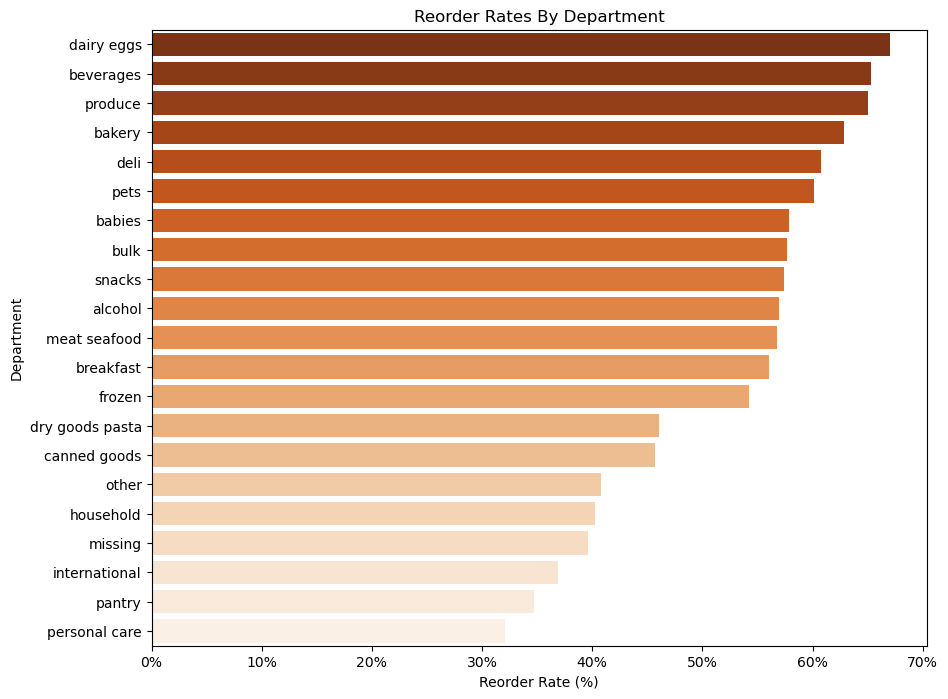

In [348]:
reorder_rate_dept = (
    order_dept_aisles
        .groupby("department")["reordered"]
        .mean()
        .reset_index(name="reorder_rate")
        .sort_values("reorder_rate", ascending=False)
)


plt.figure(figsize=(10, 8))
sns.barplot(
    data=reorder_rate_dept.sort_values("reorder_rate", ascending=False),
    y="department",
    x="reorder_rate",
    palette="Oranges_r"
)

plt.title("Reorder Rates By Department")
plt.xlabel("Reorder Rate (%)")
plt.ylabel("Department")

# Format x-axis as percentage
plt.gca().xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))

plt.show()

##### reorder rates by aisle

In [278]:
reorder_rate_aisles = (
    order_dept_aisles
        .groupby("aisle")["reordered"]
        .mean()
        .reset_index(name="reorder_rate")
        .sort_values("reorder_rate", ascending=False)
)

reorder_rate_aisles["reorder_rate"] = reorder_rate_aisles["reorder_rate"].apply(lambda x: f"{x:.2%}")
reorder_rate_aisles

,aisle,reorder_rate
83,milk,78.14%
131,water seltzer sparkling water,72.96%
50,fresh fruits,71.81%
41,eggs,70.54%
119,soy lactosefree,69.26%
...,...,...
8,beauty,21.21%
76,kitchen supplies,19.54%
47,first aid,19.48%
7,baking supplies decor,16.72%
